## **Collaborators**: Rachit Mehta, Kaushal Bule, Luv Agarwal, Akash KP, Prateek Taksha

# Q1 Greedy algorithm for the densest subgraph

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
edges_data = pd.read_csv('./facebook_large/musae_facebook_edges.csv')
total_edges = len(edges_data)
print("Totak Edges: ",total_edges)
edges_data

Totak Edges:  171002


,id_1,id_2
0,0,18427
1,1,21708
2,1,22208
3,1,22171
4,1,6829
...,...,...
170997,20188,20188
170998,22340,22383
170999,22348,22348
171000,5563,5563


In [7]:
target = pd.read_csv('./facebook_large/musae_facebook_target.csv')
total_nodes = target.shape[0]
print("Total Node: ", total_nodes)
target

Total Node:  22470


,id,facebook_id,page_name,page_type
0,0,145647315578475,The Voice of China 中国好声音,tvshow
1,1,191483281412,U.S. Consulate General Mumbai,government
2,2,144761358898518,ESET,company
3,3,568700043198473,Consulate General of Switzerland in Montreal,government
4,4,1408935539376139,Mark Bailey MP - Labor for Miller,politician
...,...,...,...,...
22465,22465,1379955382222841,Kurt Wiegel MdL,politician
22466,22466,1651527995097082,dubdub Stories,company
22467,22467,155369444540412,Ministerio del Interior - Paraguay,government
22468,22468,175067819212798,Tottus Perú,company


In [8]:
import heapq
adj = [[] for _ in range(total_nodes)]
degrees = np.zeros(total_nodes, dtype=int)

for u, v in edges_data.values:
    adj[u].append(v)
    adj[v].append(u)
    degrees[u] += 1
    degrees[v] += 1

total_density = np.sum(degrees) / (2 * total_nodes)
print('The total density of the entire graph is:', total_density)

heap = [(degrees[i], i) for i in range(total_nodes)]
heapq.heapify(heap)
degree_map = dict(enumerate(degrees))
active_nodes = set(range(total_nodes))

max_density = -np.inf
max_density_subgraph = 0
subgraphs = []

for iter in range(total_nodes):
    while heap:
        min_degree, min_degree_node = heapq.heappop(heap)
        if min_degree_node in active_nodes and degree_map[min_degree_node] == min_degree:
            break 
    else:
        break  
    subgraph = []
    active_nodes.remove(min_degree_node)  

    for neighbor in adj[min_degree_node]:
        if neighbor in active_nodes:
            degree_map[neighbor] -= 1
            heapq.heappush(heap, (degree_map[neighbor], neighbor))  

    eSS = sum(degree_map[n] for n in active_nodes) / 2
    mod_S = len(active_nodes)

    if mod_S == 0:
        break

    subgraph = list(active_nodes)
    subgraphs.append(subgraph)
    density_subgraph = eSS / mod_S
    if density_subgraph > max_density:
        max_density = density_subgraph
        max_density_subgraph = iter

densest_subgraph_nodes = subgraphs[max_density_subgraph]
print(f"Densest subgraph found with density: {max_density}")

The total density of the entire graph is: 7.610235870048954
Densest subgraph found with density: 35.00625


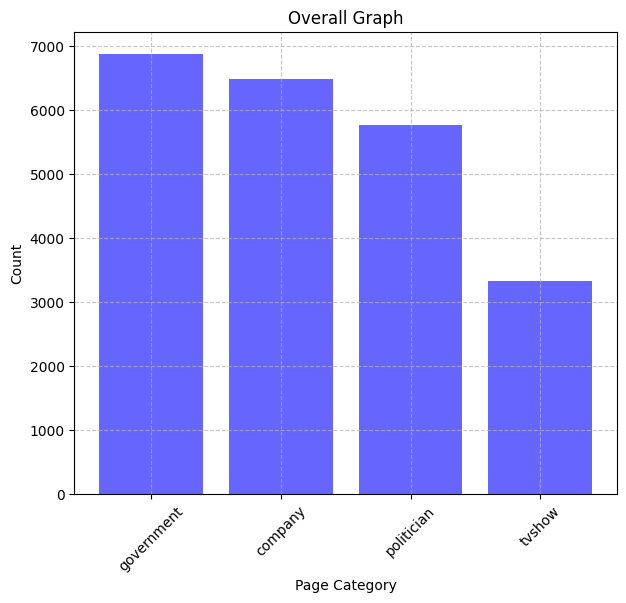

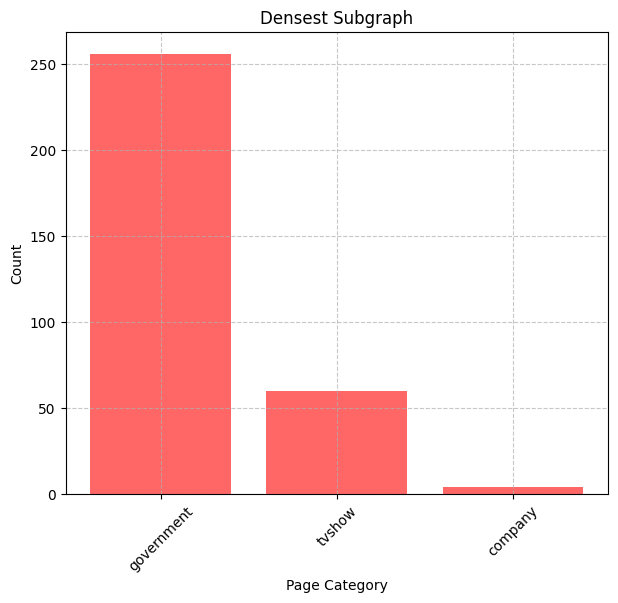

Overall Page Category Distribution:  page_type
government    6880
company       6495
politician    5768
tvshow        3327
Name: count, dtype: int64
Densest Subgraph Page Category Distribution:  page_type
government    256
tvshow         60
company         4
Name: count, dtype: int64
Comparison: The densest subgraph appears to have a higher concentration of certain categories compared to the entire graph.


In [9]:
all_page_categories = target['page_type'].value_counts()
subgraph_categories = target.loc[densest_subgraph_nodes, 'page_type'].value_counts()

plt.figure(figsize=(7, 6))  
plt.bar(all_page_categories.index, all_page_categories.values, alpha=0.6, color='b')
plt.title("Overall Graph")
plt.xlabel("Page Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)  
plt.show()

plt.figure(figsize=(7, 6)) 
plt.bar(subgraph_categories.index, subgraph_categories.values, alpha=0.6, color='r')
plt.title("Densest Subgraph")
plt.xlabel("Page Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)  
plt.show()

print("Overall Page Category Distribution: ", all_page_categories)
print("Densest Subgraph Page Category Distribution: ", subgraph_categories)
print("Comparison: The densest subgraph appears to have a higher concentration of certain categories compared to the entire graph.")

In the overall graph, the distribution of page categories is relatively balanced, with government, company, politician, and TV show pages all having significant representation. Government and company pages are the most common, while TV show pages are the least frequent in the densest subgraph. However, in the densest subgraph, the structure is dominated by government pages, with over 250 occurrences, while TV show pages remain present but in much lower numbers. Notably, politician pages, which were prominent in the overall graph, are completely absent from the densest subgraph, indicating that they do not contribute to the most interconnected regions. The company category also has a minimal presence in the densest subgraph. This suggests that government and TV show pages form highly interconnected clusters, while politician and company pages may be more sparsely connected in the overall graph.

# Q2 Implementation of spartest cut and its conductance

In [10]:
email_edges = pd.read_csv('email-Eu-core.txt', sep=' ', header=None, names=['source', 'target'])
total_edges = len(email_edges)
print("Total Edges: ",total_edges)
email_edges

Total Edges:  25571


,source,target
0,0,1
1,2,3
2,2,4
3,5,6
4,5,7
...,...,...
25566,420,143
25567,174,859
25568,440,460
25569,52,786


In [11]:
department_df = pd.read_csv('email-Eu-core-department-labels.txt', sep=' ', header=None, names=['node', 'department'])
total_nodes = department_df['node'].nunique()
print("Total Node: ", total_nodes)
department_df

Total Node:  1005


,node,department
0,0,1
1,1,1
2,2,21
3,3,21
4,4,21
...,...,...
1000,1000,4
1001,1001,21
1002,1002,1
1003,1003,6


In [12]:
adj = np.zeros((total_nodes, total_nodes), dtype=int)
D = np.zeros(total_nodes, dtype=int)

for u, v in email_edges.values:
    if u != v:  
        adj[u, v] = adj[v, u] = 1  
        D[u] += 1
        D[v] += 1

def dfs(node, adj, visited, component):
    stack = [node]
    while stack:
        v = stack.pop()
        if not visited[v]:
            visited[v] = True
            component.append(v)
            stack.extend(np.where(adj[v] == 1)[0]) 

num_nodes = adj.shape[0]
visited = np.zeros(num_nodes, dtype=bool)
largest_component = []

for node in range(num_nodes):
    if not visited[node] and np.any(adj[node]): 
        component = []
        dfs(node, adj, visited, component)
        if len(component) > len(largest_component):
            largest_component = component

largest_component = np.array(largest_component)
adj = adj[np.ix_(largest_component, largest_component)] 
D = np.sum(adj, axis=1)  
D[D == 0] = 1
D_inv_sqrt = np.diag(1 / np.sqrt(D))
L_norm = np.eye(len(largest_component)) - np.dot(np.dot(D_inv_sqrt, adj), D_inv_sqrt)
print("Number of nodes in largest component is", len(largest_component))

Number of nodes in largest component is 986


In [13]:
from scipy.sparse.linalg import eigsh

eigenvalues, eigenvectors = eigsh(L_norm, k=2, which='SM')
second_eigenvalue = eigenvalues[1]  
second_eigenvector = eigenvectors[:, 1]
print("Second smallest eigenvalue:", second_eigenvalue)

nodes = np.arange(len(second_eigenvector))
sorted_nodes = sorted(zip(nodes, second_eigenvector), key=lambda x: x[1])
degree_left = 0
degree_right = np.sum(D)
cut_edges = 0
min_conductance = float("inf")
sparsest_cut = ([], [])

for i in range(1, len(sorted_nodes) - 1):
    node, _ = sorted_nodes[i]
    node_degree = D[node]
    degree_left += node_degree
    degree_right -= node_degree
    cut_edges += np.sum(adj[node, [n[0] for n in sorted_nodes[i:]]]) - \
                 np.sum(adj[node, [n[0] for n in sorted_nodes[:i]]])
    conductance = cut_edges / min(degree_left, degree_right)
    if conductance < min_conductance:
        min_conductance = conductance
        sparsest_cut = (
            [sorted_nodes[j][0] for j in range(i)],
            [sorted_nodes[j][0] for j in range(i, len(sorted_nodes))]
        )

print("Size of first partition:", len(sparsest_cut[0]))
print("Size of second partition:", len(sparsest_cut[1]))
print("Minimum conductance:", min_conductance)

Second smallest eigenvalue: 0.21214955108262268
Size of first partition: 81
Size of second partition: 905
Minimum conductance: 0.2506908803789972


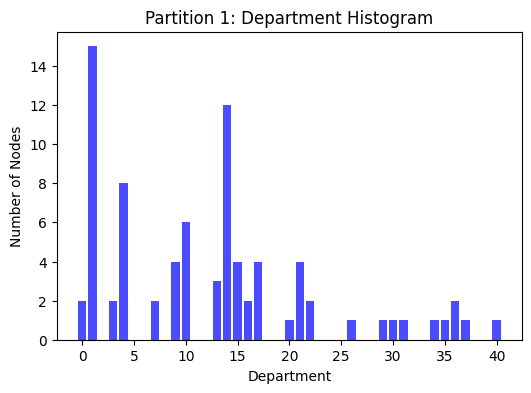

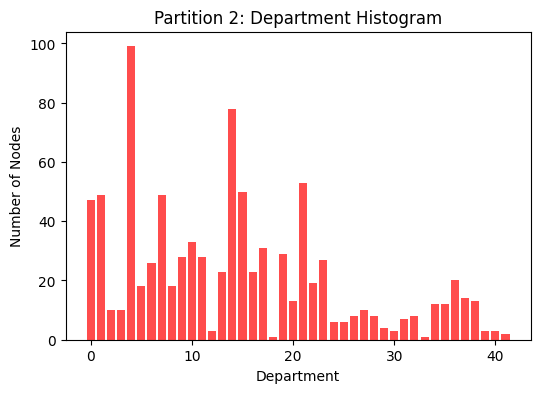

In [14]:
department_labels = department_df.to_numpy()
departments_cut1 = department_labels[sparsest_cut[0], 1] 
departments_cut2 = department_labels[sparsest_cut[1], 1]
hist_cut1 = np.bincount(departments_cut1)
hist_cut2 = np.bincount(departments_cut2)

plt.figure(figsize=(6, 4))
plt.bar(range(len(hist_cut1)), hist_cut1, color='b', alpha=0.7)
plt.xlabel("Department")
plt.ylabel("Number of Nodes")
plt.title("Partition 1: Department Histogram")
plt.show()

plt.figure(figsize=(6, 4))
plt.bar(range(len(hist_cut2)), hist_cut2, color='r', alpha=0.7)
plt.xlabel("Department")
plt.ylabel("Number of Nodes")
plt.title("Partition 2: Department Histogram")
plt.show()

# Q3 Comparison of k-mean and k-median distance

In [15]:
import numpy as np
from sklearn.cluster import KMeans
np.random.seed(42)

data1 = np.random.normal(0, 1, size=100)
data2 = np.random.normal(3, 1, size=100)
data = np.concatenate([data1, data2]).reshape(-1, 1)

kmeans = KMeans(n_clusters=2, random_state=42,n_init=10)
kmeans.fit(data)

kmeans_centers = kmeans.cluster_centers_

true_labels = np.concatenate([np.zeros(100), np.ones(100)])
sorted_center = np.sort(kmeans_centers.flatten())
pred_labels = (data.flatten() > sorted_center.mean()).astype(int)
kmeans_accuracy = np.mean(pred_labels==true_labels)

sorted_data = data[np.argsort(data.flatten())].flatten()
sorted_true_labels = true_labels[np.argsort(data.flatten())]

best_median_cost = float("inf")
best_median_centers = None
best_median_labels = None
best_split = 0

for s in range(1, 200):
    cluster1 = sorted_data[:s]
    cluster2 = sorted_data[s:]
    
    median1 = np.median(cluster1)
    median2 = np.median(cluster2)
    median_cost = np.sum(np.abs(cluster1 - median1)) + np.sum(np.abs(cluster2 - median2))
    
    if median_cost < best_median_cost:
        best_median_cost = median_cost
        best_median_centers = (median1, median2)
        best_split = s

kmedian_accuracy = max(
    np.mean(sorted_true_labels[:best_split] == 0) + np.mean(sorted_true_labels[best_split:] == 1),
    np.mean(sorted_true_labels[:best_split] == 1) + np.mean(sorted_true_labels[best_split:] == 0)
) / 2


print(f"K-Means: Centers: [{', '.join(f'{x:.4f}' for x in sorted_center)}], Accuracy: {kmeans_accuracy:.4f}")
print(f"K-Medians: Centers: [{', '.join(f'{x:.4f}' for x in best_median_centers)}], Accuracy: {kmedian_accuracy:.4f}, Best split s: {best_split}")

if kmeans_accuracy > kmedian_accuracy:
    print("K-Means (Squared Distance) is better for this generated dataset")
else:
    print("K-Medians (Distance) is better for this generated dataset")


K-Means: Centers: [-0.2160, 2.9448], Accuracy: 0.9600
K-Medians: Centers: [-0.2197, 3.0582], Accuracy: 0.9561, Best split s: 95
K-Means (Squared Distance) is better for this generated dataset


# Q4 Implementation of Bloom Filter

Optimal m for 5% false positive rate: 6235224
k=2, False Positive Rate: 0.0788
k=4, False Positive Rate: 0.0452
k=6, False Positive Rate: 0.0516
k=8, False Positive Rate: 0.0708
k=10, False Positive Rate: 0.1152
k=12, False Positive Rate: 0.1584


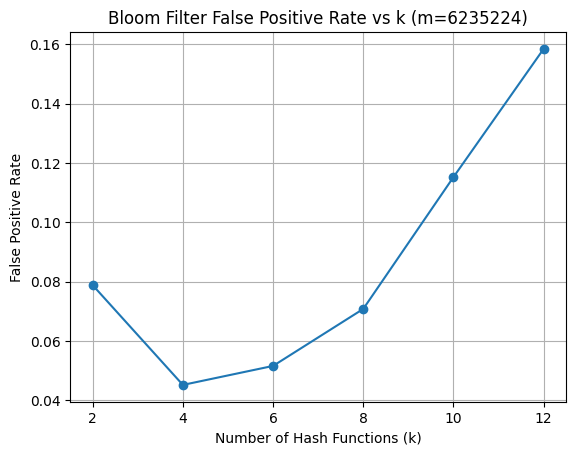

Optimal k: 4 with false positive rate: 0.0452


In [16]:
import random
import hashlib
from scipy.optimize import fsolve

random.seed(42)
def hash_with_seed(data, seed, m):
    hash_obj = hashlib.md5((str(seed) + data).encode())
    return int(hash_obj.hexdigest(), 16) % m

class BloomFilter:
    def __init__(self, m, k):
        self.m = m
        self.k = k
        self.bit_array = np.zeros(m, dtype=bool)
    
    def insert(self, item):
        for seed in range(self.k):
            index = hash_with_seed(item, seed, self.m)
            self.bit_array[index] = True
    
    def query(self, item):
        return all(self.bit_array[hash_with_seed(item, seed, self.m)] for seed in range(self.k))

def generate_random_string(length=100):
    return ''.join(np.random.choice(list('abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789'), length))

n = 10**6 
target_fpr = 0.05 

def fpr_equation(m):
    k_opt = (m / n) * np.log(2) 
    return (1 - np.exp(-k_opt * n / m)) ** k_opt - target_fpr

m_optimal = int(fsolve(fpr_equation, n * 10)[0])  
print(f"Optimal m for 5% false positive rate: {m_optimal}")

k_values = [2, 4, 6, 8, 10, 12]
corpus_size = n
query_size = 5000
corpus = {generate_random_string() for _ in range(corpus_size)}
corpus_list = list(corpus)

queries_in_corpus = np.random.choice(corpus_list, query_size // 2, replace=False).tolist()
queries_not_in_corpus = [generate_random_string() for _ in range(query_size // 2)]
queries = queries_in_corpus + queries_not_in_corpus
np.random.shuffle(queries)

queries_not_in_corpus = [data for data in queries if data not in corpus]
false_positive_rates = []

for k in k_values:
    bf = BloomFilter(m_optimal, k)
    
    for item in corpus:
        bf.insert(item)
    
    false_positives = sum(1 for q in queries_not_in_corpus if bf.query(q))
    false_positive_rate = false_positives / len(queries_not_in_corpus)
    false_positive_rates.append(false_positive_rate)
    print(f"k={k}, False Positive Rate: {false_positive_rate:.4f}")

plt.plot(k_values, false_positive_rates, marker='o', linestyle='-')
plt.xlabel('Number of Hash Functions (k)')
plt.ylabel('False Positive Rate')
plt.title(f'Bloom Filter False Positive Rate vs k (m={m_optimal})')
plt.grid()
plt.show()

idx = false_positive_rates.index(min(false_positive_rates))
optimal_k = k_values[idx]
optimal_fp = false_positive_rates[idx]
print(f"Optimal k: {optimal_k} with false positive rate: {optimal_fp:.4f}")
